# markouts — what happens to the price right after our fills

A **markout** asks one question: when one of our orders traded, where did the price go in the
seconds after? If we buy and the price then rises, the fill earned its keep. If we buy and the
price falls, we were on the wrong side — someone traded with us because they knew (or the flow
knew) where the price was going. That is *toxic flow*, and it is the tax every market maker pays.

Sign convention, both sides, everywhere in this notebook: **negative = the price moved against
us after the fill**. Units are basis points (1 bp = 0.01% of the price, ≈ $6.34 at this
session's BTC price).

The data is a ~94-minute recording of the `strat-micro-recorder` engine quoting BTCUSDT on
Binance spot against the built-in exchange simulator (`mode: sim`): real market data, simulated
fills. One caveat to hold in mind throughout: the simulator's fill model is *optimistic* (it
assumes queue cancellations happen behind us, and it cannot see hidden liquidity), so the real
numbers would likely be somewhat **worse** than what follows.

Run: `uv sync` in `strategies/`, pick the `.venv` kernel, run all cells. Any sealed sim capture
of this engine works — nothing below is hard-coded to this session.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import datetime as dt

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import etl

RUN = etl.find_run("../../data", "strat-micro-recorder", "te-binance-spot-btcusdt", mode="sim")
long, footer, empty = etl.load_features(RUN)
fills, _ = etl.load_table(RUN, "fills")
orders, _ = etl.load_table(RUN, "orders")

TICK = 0.01
HORIZONS = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60]
SEED = 7

mid = etl.feature_series(long, "mid").rename({"mid": "m"})
MID_MEAN = mid["m"].mean()
BPS_PER_TICK = TICK / MID_MEAN * 1e4

# Dropping the never-emitted columns up front: analysing a column with no rows is analysing air.
print(f"run           {RUN}")
print(f"execution     {footer['execution_mode']}  (fills are simulated, market data is real)")
lo, hi = long["event_ts_us"].min(), long["event_ts_us"].max()
t0 = dt.datetime.fromtimestamp(lo / 1e6, dt.UTC)
t1 = dt.datetime.fromtimestamp(hi / 1e6, dt.UTC)
print(f"session       {t0:%Y-%m-%d %H:%M} -> {t1:%H:%M} UTC  ({(hi - lo) / 60e6:.0f} min)")
print(f"features      {long.height:,} rows, {len(footer['feature_dictionary'])} declared")
print(f"empty columns dropped ({len(empty)}): {', '.join(empty)}")
print(f"fills         {fills.height} ({fills.filter(pl.col('side') == 'buy').height} buys, "
      f"{fills.filter(pl.col('side') == 'sell').height} sells)")
print(f"mid           {MID_MEAN:,.0f} avg; 1 tick = {BPS_PER_TICK:.5f} bps; 1 bp = ${MID_MEAN / 1e4:.2f}")

run           ../../data/strat-micro-recorder/te-binance-spot-btcusdt/sim
execution     sim  (fills are simulated, market data is real)
session       2026-08-13 20:12 -> 21:46 UTC  (94 min)
features      868,110 rows, 77 declared
empty columns dropped (6): vpin_st, vpin_lt, vpin_signed_flow_st, vpin_signed_flow_lt, poly_next_up_intensity_a_bid, poly_next_up_intensity_k_bid
fills         173 (80 buys, 93 sells)
mid           63,438 avg; 1 tick = 0.00158 bps; 1 bp = $6.34


In [2]:
BUY, SELL = "#2a78d6", "#eb6834"
INK, SEC, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, RED = "#e1e0d9", "#c3c2b7", "#d03b3b"

mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": SEC, "axes.edgecolor": BASE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9.5,
})
HHMM = mpl.dates.DateFormatter("%H:%M", tz=dt.UTC)


def ts_col(df, col):
    return df.select(pl.from_epoch(col, time_unit="us").alias("t"))["t"].to_numpy()


def asof(base_df, on, target, name, strategy="backward", tolerance=None):
    right = target.rename({"event_ts_us": on, target.columns[1]: name})
    kwargs = {"tolerance": tolerance} if tolerance else {}
    return (base_df.sort(on).join_asof(right, on=on, strategy=strategy, **kwargs))

In [3]:
# Every quantity that describes the moment of a fill, joined once, used everywhere below.
sign = pl.when(pl.col("side") == "buy").then(1.0).otherwise(-1.0)
pf = fills.sort("received_ts_us").with_columns(
    pl.col("last_price").alias("px"), sign.alias("sign"), pl.col("booked_quote").alias("notional")
)

pf = asof(pf, "received_ts_us", mid, "mid_at_fill")
pf = pf.with_columns((pl.col("sign") * (pl.col("mid_at_fill") - pl.col("px")) / pl.col("px") * 1e4).alias("edge_bps"))

before = pf.with_columns((pl.col("received_ts_us") - 5_000_000).alias("ts_b"))
before = asof(before, "ts_b", mid, "mid_before").sort("received_ts_us")
pf = pf.sort("received_ts_us").with_columns(
    (pl.col("sign") * (before["mid_at_fill"] - before["mid_before"]) / before["mid_before"] * 1e4).alias("pre_drift_bps")
)

for feature in ["imbalance", "gueant_sigma_ticks", "inventory_quote", "realised_vol_st"]:
    pf = asof(pf, "received_ts_us", etl.feature_series(long, feature), feature)
pf = pf.with_columns((pl.col("imbalance") * pl.col("sign")).alias("signed_imb"))

placed = orders.filter(pl.col("transition") == "placed").select("client_order_id", pl.col("received_ts_us").alias("placed_ts_us"))
pf = pf.join(placed, on="client_order_id", how="left").with_columns(
    ((pl.col("received_ts_us") - pl.col("placed_ts_us")) / 1e6).alias("ttf_secs")
).sort("received_ts_us")

# Fee measured from the recorded commissions, never assumed. Buy fees arrive in BTC, sell fees
# in USDT (commission_asset_id indexes the footer's asset dictionary).
assets = footer["asset_dictionary"]
fee_quote = pl.when(pl.col("commission_asset_id") == assets.index("USDT")) \
    .then(pl.col("commission")).otherwise(pl.col("commission") * pl.col("px"))
pf = pf.with_columns((fee_quote / pl.col("notional") * 1e4).alias("fee_bps"))
FEE_BPS = pf["fee_bps"].median()

funnel = orders.group_by("transition").agg(pl.len().alias("n"))
n_of = dict(funnel.iter_rows())
print(f"order funnel  {n_of.get('placed', 0)} placed -> {n_of.get('cancel_sent', 0)} cancels sent, "
      f"{pf.filter(pl.col('ttf_secs').is_not_null()).height} fills matched to a placement")
print(f"maker fee     {FEE_BPS:.2f} bps of notional per fill (measured; both sides)")
print(f"time-to-fill  p10 {pf['ttf_secs'].quantile(0.1):.1f}s  p50 {pf['ttf_secs'].quantile(0.5):.1f}s  "
      f"p90 {pf['ttf_secs'].quantile(0.9):.1f}s")
print(f"edge at fill  buys +{pf.filter(pl.col('side') == 'buy')['edge_bps'].mean():.2f} bps, "
      f"sells +{pf.filter(pl.col('side') == 'sell')['edge_bps'].mean():.2f} bps vs the mid at the fill")

order funnel  676 placed -> 632 cancels sent, 173 fills matched to a placement
maker fee     10.00 bps of notional per fill (measured; both sides)
time-to-fill  p10 0.6s  p50 7.2s  p90 34.7s
edge at fill  buys +0.09 bps, sells +0.27 bps vs the mid at the fill


## The session at a glance

Price on top with every fill marked; our inventory below. **Takeaway:** fills cluster on the
price swings rather than arriving evenly, and the inventory spends long stretches pinned near
its −$50 cap — the strategy was short for most of the session, trying to buy its way back.

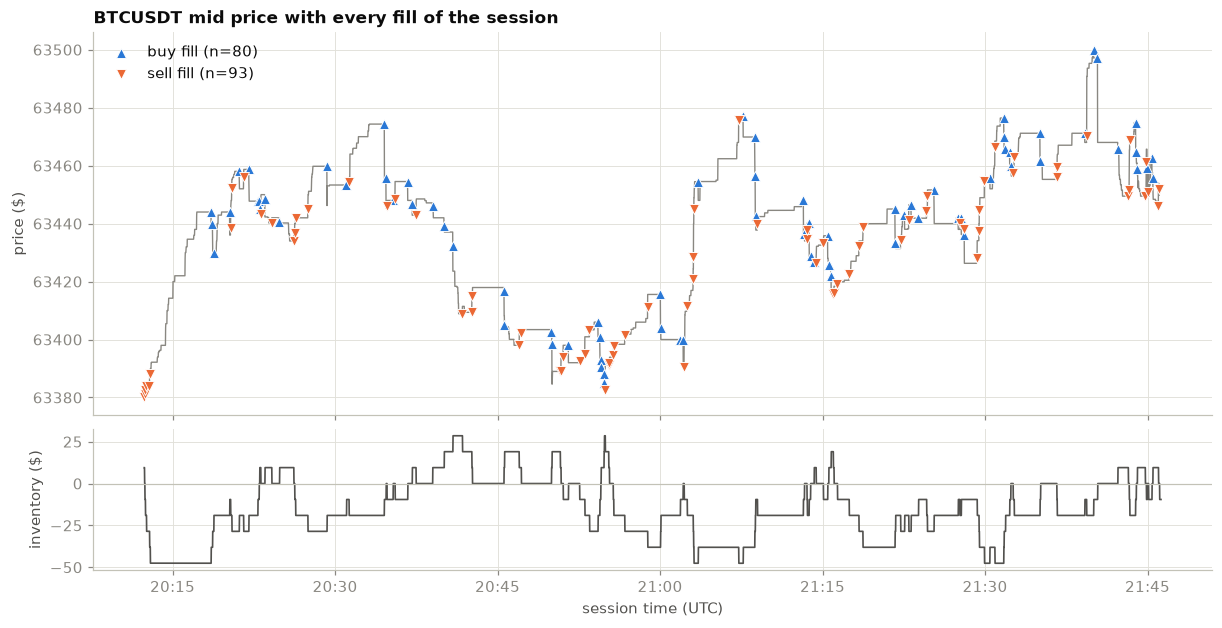

In [4]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                              height_ratios=[3, 1.1], constrained_layout=True)

ax.plot(ts_col(mid, "event_ts_us"), mid["m"], color=MUTED, lw=0.9, zorder=1)
for side, color, marker in [("buy", BUY, "^"), ("sell", SELL, "v")]:
    sub = pf.filter(pl.col("side") == side)
    ax.scatter(ts_col(sub, "received_ts_us"), sub["px"], s=42, marker=marker, color=color,
               edgecolor="white", linewidth=0.6, zorder=3, label=f"{side} fill (n={sub.height})")
ax.set_title("BTCUSDT mid price with every fill of the session")
ax.set_ylabel("price ($)")
ax.legend(loc="upper left")

inv = etl.feature_series(long, "inventory_quote")
ax2.plot(ts_col(inv, "event_ts_us"), inv["inventory_quote"], color=SEC, lw=1.1)
ax2.axhline(0, color=BASE, lw=0.8)
ax2.set_ylabel("inventory ($)")
ax2.xaxis.set_major_formatter(HHMM)
ax2.set_xlabel("session time (UTC)")
plt.show()

## Measuring the markouts

For every fill we look at the mid price 1 to 60 seconds later and score the move from our side
of the trade (negative = against us). Because fills arrive in bursts that share the same price
move, treating each fill as independent would overstate our confidence — so fills are grouped
into **clusters** separated by at least 60 quiet seconds, and confidence intervals come from
resampling whole clusters (10,000 draws).

**Takeaway:** every row of the table below is negative — both sides, every horizon — and almost
every confidence interval sits entirely below zero. 92–98% of individual fills were underwater
five seconds after trading. This is not noise; it is systematic.

In [5]:
rng = np.random.default_rng(SEED)

for h in HORIZONS:
    later = pf.with_columns((pl.col("received_ts_us") + h * 1_000_000).alias("ts_h"))
    later = asof(later, "ts_h", mid, "mid_later", strategy="forward", tolerance=2_500_000)
    later = later.sort("received_ts_us")
    pf = pf.with_columns(
        (later["sign"] * (later["mid_later"] - later["px"]) / later["px"] * 1e4).alias(f"mo_{h}s")
    )
dropped = sum(pf[f"mo_{h}s"].null_count() for h in HORIZONS)
print(f"{dropped} fill-horizon pairs dropped (mid gap or session end) out of {pf.height * len(HORIZONS)}")

gap_us = 60_000_000
pf = pf.with_columns(
    (pl.col("received_ts_us").diff().fill_null(gap_us + 1).ge(gap_us)).cum_sum().over("side").alias("cluster")
)


def cluster_boot(frame, col, n_draws=10_000):
    """Bootstrap the mean by resampling whole fill clusters, keeping burst correlation intact."""
    groups = frame.filter(pl.col(col).is_not_null()).group_by("cluster").agg(
        pl.col(col).sum().alias("s"), pl.len().alias("n"))
    s, n = groups["s"].to_numpy(), groups["n"].to_numpy().astype(float)
    if len(s) == 0:
        return np.nan, (np.nan, np.nan)
    idx = rng.integers(0, len(s), size=(n_draws, len(s)))
    means = s[idx].sum(axis=1) / n[idx].sum(axis=1)
    return s.sum() / n.sum(), tuple(np.percentile(means, [2.5, 97.5]))


rows = []
for side in ["buy", "sell"]:
    sub = pf.filter(pl.col("side") == side)
    n_clusters = sub["cluster"].n_unique()
    for h in [1, 3, 5, 15, 30, 60]:
        x = sub[f"mo_{h}s"].drop_nulls()
        mean, (lo, hi) = cluster_boot(sub, f"mo_{h}s")
        rows.append({"side": side, "h": h, "n": len(x), "clusters": n_clusters,
                     "mean_bps": round(mean, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
                     "median": round(x.median(), 3), "pct_negative": round((x < 0).mean() * 100)})
summary = pl.DataFrame(rows)
with pl.Config(tbl_rows=20):
    print(summary)

13 fill-horizon pairs dropped (mid gap or session end) out of 1730


shape: (12, 9)
┌──────┬─────┬─────┬──────────┬───┬────────┬────────┬────────┬──────────────┐
│ side ┆ h   ┆ n   ┆ clusters ┆ … ┆ ci_lo  ┆ ci_hi  ┆ median ┆ pct_negative │
│ ---  ┆ --- ┆ --- ┆ ---      ┆   ┆ ---    ┆ ---    ┆ ---    ┆ ---          │
│ str  ┆ i64 ┆ i64 ┆ i64      ┆   ┆ f64    ┆ f64    ┆ f64    ┆ i64          │
╞══════╪═════╪═════╪══════════╪═══╪════════╪════════╪════════╪══════════════╡
│ buy  ┆ 1   ┆ 80  ┆ 29       ┆ … ┆ -1.023 ┆ -0.726 ┆ -0.725 ┆ 94           │
│ buy  ┆ 3   ┆ 80  ┆ 29       ┆ … ┆ -1.208 ┆ -0.827 ┆ -0.789 ┆ 94           │
│ buy  ┆ 5   ┆ 80  ┆ 29       ┆ … ┆ -1.209 ┆ -0.79  ┆ -0.782 ┆ 92           │
│ buy  ┆ 15  ┆ 80  ┆ 29       ┆ … ┆ -1.21  ┆ -0.671 ┆ -0.928 ┆ 80           │
│ buy  ┆ 30  ┆ 80  ┆ 29       ┆ … ┆ -1.269 ┆ -0.543 ┆ -0.915 ┆ 71           │
│ buy  ┆ 60  ┆ 78  ┆ 29       ┆ … ┆ -1.103 ┆ -0.156 ┆ -0.919 ┆ 69           │
│ sell ┆ 1   ┆ 93  ┆ 31       ┆ … ┆ -0.616 ┆ -0.353 ┆ -0.329 ┆ 98           │
│ sell ┆ 3   ┆ 93  ┆ 31       ┆ … ┆ -0.838 ┆ -0.4

## The markout curves

Left: the average path of the price after our fills, out to one minute, with 95% confidence
bands. Right: the distribution of the individual 5-second markouts.

**Takeaway:** within one second of a fill the price has already moved about half to one basis
point against us, and it never comes back — the curve stays down for the whole minute. There is
no bounce to harvest; the fills are simply on the wrong side of where the price is going.

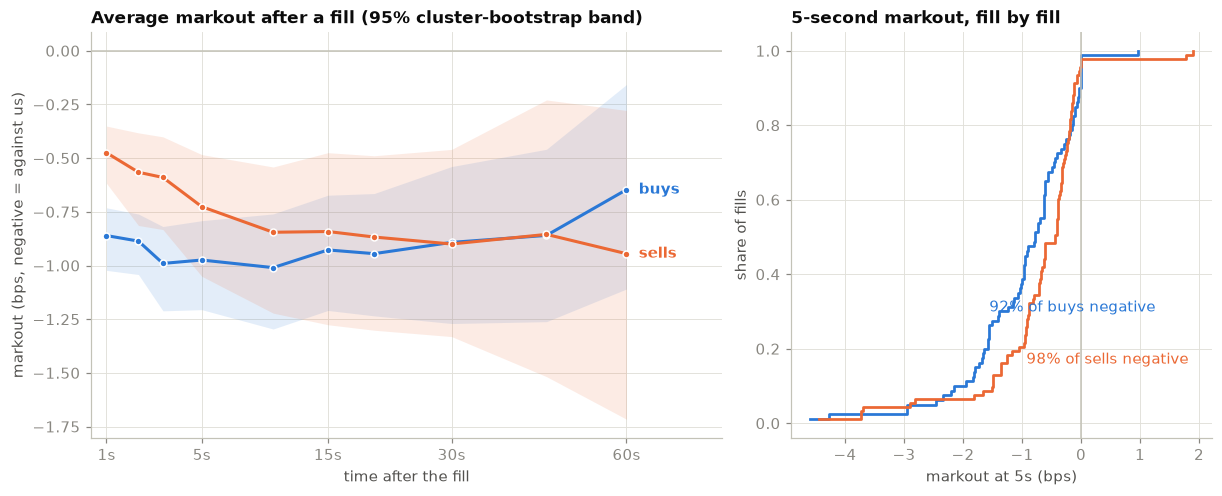

In [6]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True, width_ratios=[1.5, 1])

xpos = np.sqrt(HORIZONS)
for side, color in [("buy", BUY), ("sell", SELL)]:
    sub = pf.filter(pl.col("side") == side)
    means, los, his = [], [], []
    for h in HORIZONS:
        mean, (lo, hi) = cluster_boot(sub, f"mo_{h}s")
        means.append(mean); los.append(lo); his.append(hi)
    ax.plot(xpos, means, color=color, lw=2, marker="o", ms=4.5, markeredgecolor="white")
    ax.fill_between(xpos, los, his, color=color, alpha=0.13, lw=0)
    ax.annotate(f"{side}s", (xpos[-1], means[-1]), xytext=(8, 0), textcoords="offset points",
                color=color, fontweight="bold", va="center")
ax.axhline(0, color=BASE, lw=1)
ax.set_xticks(np.sqrt([1, 5, 15, 30, 60]), ["1s", "5s", "15s", "30s", "60s"])
ax.set_xlim(0.8, np.sqrt(60) * 1.16)
ax.set_title("Average markout after a fill (95% cluster-bootstrap band)")
ax.set_xlabel("time after the fill")
ax.set_ylabel("markout (bps, negative = against us)")

for side, color in [("buy", BUY), ("sell", SELL)]:
    x = np.sort(pf.filter(pl.col("side") == side)["mo_5s"].drop_nulls().to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    ax2.step(x, y, where="post", color=color, lw=1.8)
    share = (x < 0).mean()
    ax2.annotate(f"{share:.0%} of {side}s negative", (x[int(len(x) * 0.25)], 0.30 if side == "buy" else 0.16),
                 color=color, fontsize=9.5)
ax2.axvline(0, color=BASE, lw=1)
ax2.set_title("5-second markout, fill by fill")
ax2.set_xlabel("markout at 5s (bps)")
ax2.set_ylabel("share of fills")
plt.show()

## A second, independent measurement agrees

The engine also tracks markouts its own way, live: it watches *public* trades reach the price
levels the strategy was quoting (pretend-fills, no simulator involved) and keeps a smoothed
average. Un-smoothing that average recovers the individual pretend-fill markouts. If the
simulator's fill model were inventing the toxicity, these two measurements would disagree.

**Takeaway:** the two measurements agree within their error bars on every horizon and both
sides (solid vs hollow markers, right panel). The toxicity is a property of *where the strategy
quotes*, not an artifact of how the simulator fills orders.

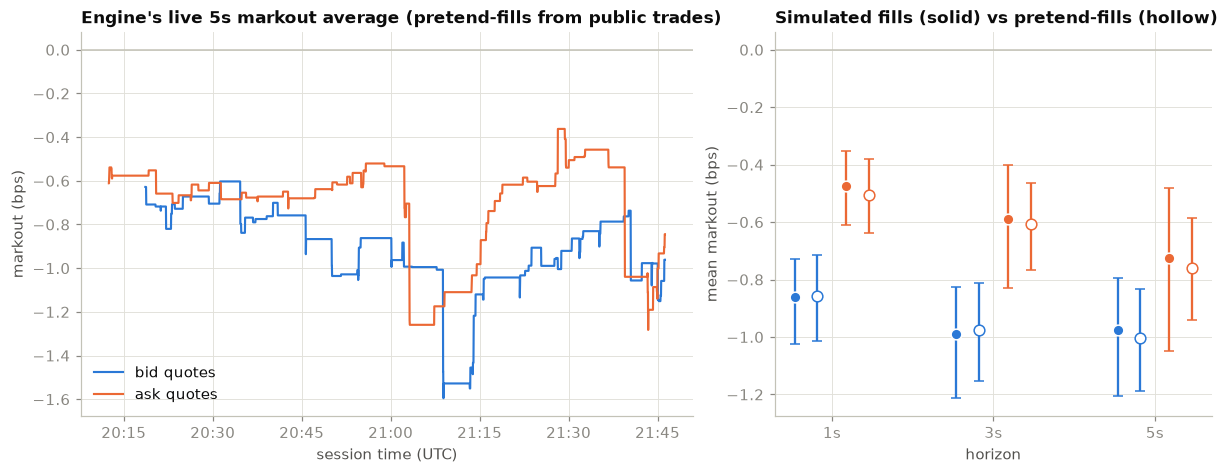

bid: recovered 97 of 98 pretend-fills, mean 5s markout -1.00 bps
ask: recovered 96 of 97 pretend-fills, mean 5s markout -0.76 bps


In [7]:
DECAY = 2 ** (-1 / 8)  # the engine smooths with an 8-fill halflife


def invert_ema(side, h):
    """Each change in the smoothed series is one newly matured pretend-fill; unwind the
    smoothing step to get its raw markout."""
    ema = etl.feature_series(long, f"markout_{side}_{h}s_bps").rename({f"markout_{side}_{h}s_bps": "e"})
    e = ema["e"].to_numpy()
    de = np.diff(e)
    raw = (e[1:] - DECAY * e[:-1]) / (1 - DECAY)
    return raw[np.abs(de) > 1e-12]


counters = {s: etl.feature_series(long, f"markout_{s}_fills")[f"markout_{s}_fills"].max() for s in ["bid", "ask"]}

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True, width_ratios=[1.4, 1])

for side, col, color in [("bid", "markout_bid_5s_bps", BUY), ("ask", "markout_ask_5s_bps", SELL)]:
    s = etl.feature_series(long, col)
    ax.plot(ts_col(s, "event_ts_us"), s[col], color=color, lw=1.4, label=f"{side} quotes")
ax.axhline(0, color=BASE, lw=1)
ax.legend(loc="lower left")
ax.set_title("Engine's live 5s markout average (pretend-fills from public trades)")
ax.set_ylabel("markout (bps)")
ax.xaxis.set_major_formatter(HHMM)
ax.set_xlabel("session time (UTC)")

offsets = {"buy": -0.16, "sell": 0.16}
pseudo_side = {"buy": "bid", "sell": "ask"}
for i, h in enumerate([1, 3, 5]):
    for side, color in [("buy", BUY), ("sell", SELL)]:
        mean, (lo, hi) = cluster_boot(pf.filter(pl.col("side") == side), f"mo_{h}s")
        ax2.errorbar(i + offsets[side] - 0.07, mean, yerr=[[mean - lo], [hi - mean]], fmt="o",
                     color=color, ms=7, capsize=3, markeredgecolor="white")
        raw = invert_ema(pseudo_side[side], h)
        boot = rng.choice(raw, size=(4000, raw.size), replace=True).mean(axis=1)
        plo, phi = np.percentile(boot, [2.5, 97.5])
        ax2.errorbar(i + offsets[side] + 0.07, raw.mean(), yerr=[[raw.mean() - plo], [phi - raw.mean()]],
                     fmt="o", color=color, ms=7, capsize=3, markerfacecolor="white")
ax2.axhline(0, color=BASE, lw=1)
ax2.set_xticks(range(3), ["1s", "3s", "5s"])
ax2.set_title("Simulated fills (solid) vs pretend-fills (hollow)")
ax2.set_ylabel("mean markout (bps)")
ax2.set_xlabel("horizon")
plt.show()

for side in ["bid", "ask"]:
    raw = invert_ema(side, 5)
    print(f"{side}: recovered {raw.size} of {counters[side]:.0f} pretend-fills, "
          f"mean 5s markout {raw.mean():+.2f} bps")

## Is there a safe pocket? Slicing the fills four ways

If the toxicity were concentrated — only the instant fills, only the fills against a lopsided
book, only the wild minutes — the fix would be a filter. Each panel splits the fills into
thirds by one condition at the moment of the fill and shows the average 5-second markout of
each third (whiskers = 95% bootstrap; with ~27 fills per dot, read direction, not precision).

**Takeaway:** there is no safe pocket. Every third of the fills — fast or slow to fill, calm or
moving market, book with us or against us — loses roughly the same ~1 basis point. Slow fills
are, if anything, slightly *worse* than instant ones, so this is not the classic "picked off by
something faster" story a speed filter could fix. The quotes are simply always too close for
how far the price wanders afterwards.

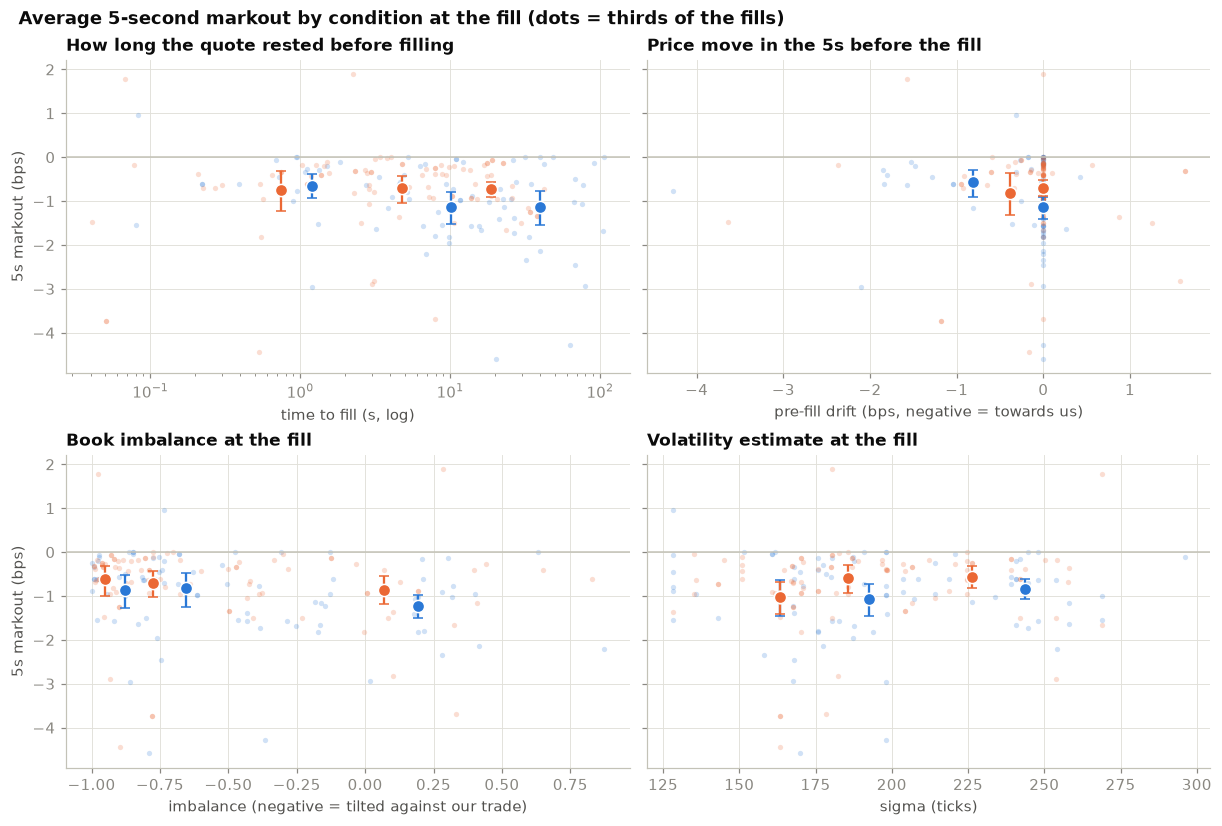

In [8]:
def tercile_panel(ax, frame, xcol, title, xlabel, log_x=False):
    for side, color in [("buy", BUY), ("sell", SELL)]:
        sub = frame.filter(pl.col("side") == side).filter(
            pl.col(xcol).is_not_null() & pl.col("mo_5s").is_not_null())
        xs, ys = sub[xcol].to_numpy(), sub["mo_5s"].to_numpy()
        ax.scatter(xs, ys, s=12, color=color, alpha=0.22, lw=0)
        edges = np.quantile(xs, [0, 1 / 3, 2 / 3, 1])
        for j in range(3):
            upper = (xs <= edges[j + 1]) if j == 2 else (xs < edges[j + 1])
            mask = (xs >= edges[j]) & upper
            if mask.sum() < 5:
                continue
            boot = rng.choice(ys[mask], size=(4000, mask.sum()), replace=True).mean(axis=1)
            lo, hi = np.percentile(boot, [2.5, 97.5])
            xm = np.median(xs[mask])
            ax.errorbar(xm, ys[mask].mean(), yerr=[[ys[mask].mean() - lo], [hi - ys[mask].mean()]],
                        fmt="o", color=color, ms=8, capsize=3, markeredgecolor="white", zorder=4)
    ax.axhline(0, color=BASE, lw=1)
    if log_x:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)


fig, axes = plt.subplots(2, 2, figsize=(11, 7.4), constrained_layout=True, sharey=True)
tercile_panel(axes[0, 0], pf, "ttf_secs", "How long the quote rested before filling", "time to fill (s, log)", log_x=True)
tercile_panel(axes[0, 1], pf, "pre_drift_bps", "Price move in the 5s before the fill", "pre-fill drift (bps, negative = towards us)")
tercile_panel(axes[1, 0], pf, "signed_imb", "Book imbalance at the fill", "imbalance (negative = tilted against our trade)")
tercile_panel(axes[1, 1], pf, "gueant_sigma_ticks", "Volatility estimate at the fill", "sigma (ticks)")
for ax in axes[:, 0]:
    ax.set_ylabel("5s markout (bps)")
fig.suptitle("Average 5-second markout by condition at the fill (dots = thirds of the fills)",
             x=0.01, ha="left", fontweight="bold")
plt.show()

## So why do we keep getting these fills? Where the strategy chose to quote

The fills are toxic on both sides, at every horizon, in every slice. The next two figures show
what the pricing model was asking for in exchange — and what each fill actually cost.

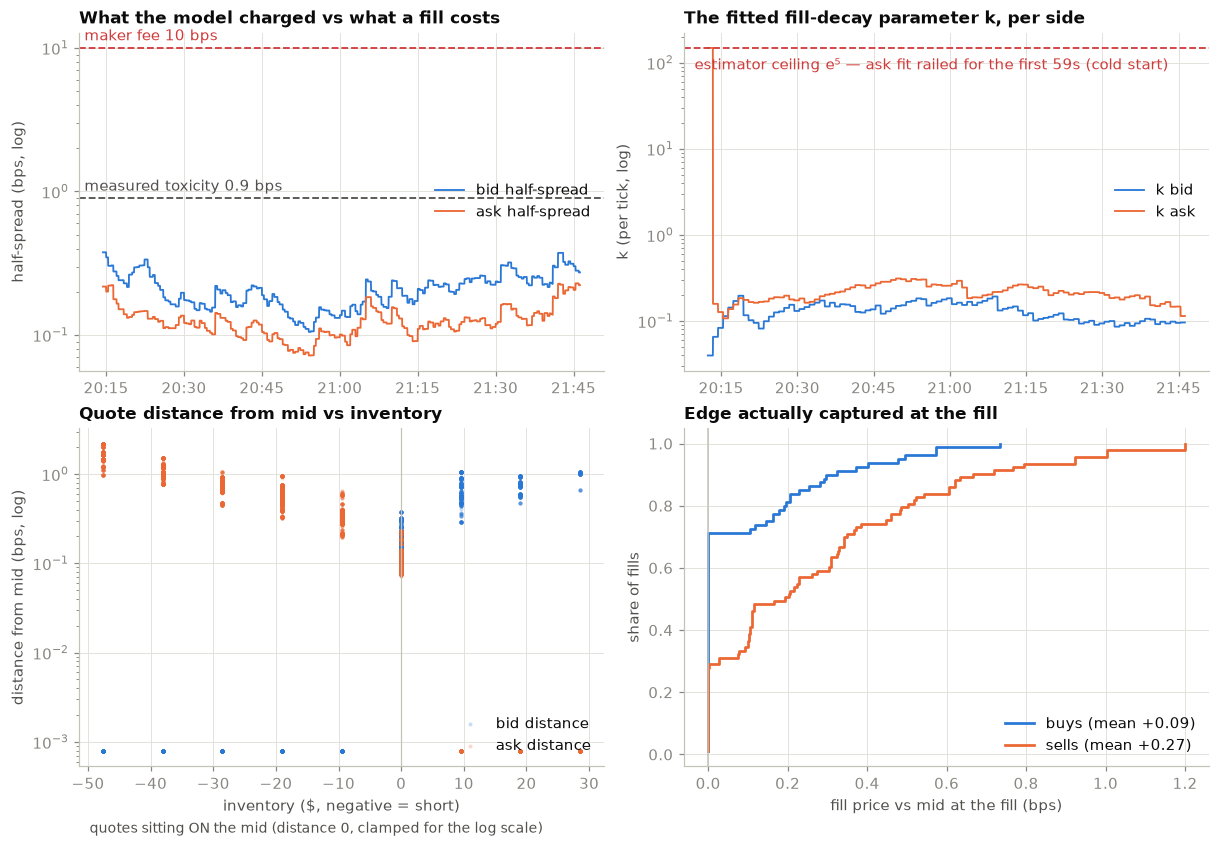

quoted half-spread, session median: bid 0.206 bps, ask 0.122 bps
break-even half-spread = fee + toxicity = 10.9 bps -> quotes are 53x too tight on the bid
share of spins quoting within one tick of mid: bid 69%, ask 13% (the inventory skew pulls the unwinding side onto the mid)
fills during the railed cold start: 6 (all ['sell']), mean 30s markout -1.16 bps vs -0.89 for the rest


In [9]:
# The half-spread panel trims the first two minutes (cold-start values near zero would
# stretch the log scale into noise); the k panel keeps them, because the cold start IS the
# story there — the fit rails at its ceiling before it has seen enough events.
T_START = long["event_ts_us"].min() + 120_000_000
warm = pl.col("event_ts_us") >= T_START
half_bid = etl.feature_series(long, "gueant_bid_half_spread_ticks").filter(warm)
half_ask = etl.feature_series(long, "gueant_ask_half_spread_ticks").filter(warm)
k_bid = etl.feature_series(long, "intensity_k_bid_per_tick")
k_ask = etl.feature_series(long, "intensity_k_ask_per_tick")

ADVERSE_BPS = abs(pf["mo_30s"].mean())
K_CEILING = float(np.exp(5))
railed = k_ask.filter(pl.col("intensity_k_ask_per_tick") > 0.999 * K_CEILING)
rail_secs = (railed["event_ts_us"].max() - long["event_ts_us"].min()) / 1e6 if railed.height else 0

fig, axes = plt.subplots(2, 2, figsize=(11, 7.6), constrained_layout=True)

ax = axes[0, 0]
for s, name, color, label in [(half_bid, "gueant_bid_half_spread_ticks", BUY, "bid"),
                              (half_ask, "gueant_ask_half_spread_ticks", SELL, "ask")]:
    ax.plot(ts_col(s, "event_ts_us"), s[name] * BPS_PER_TICK, color=color, lw=1.2, label=f"{label} half-spread")
ax.axhline(FEE_BPS, color=RED, lw=1.2, ls="--")
ax.annotate(f"maker fee {FEE_BPS:.0f} bps", (0.01, FEE_BPS), xycoords=("axes fraction", "data"),
            xytext=(0, 5), textcoords="offset points", color=RED, fontsize=9.5)
ax.axhline(ADVERSE_BPS, color=SEC, lw=1.2, ls="--")
ax.annotate(f"measured toxicity {ADVERSE_BPS:.1f} bps", (0.01, ADVERSE_BPS),
            xycoords=("axes fraction", "data"), xytext=(0, 5), textcoords="offset points",
            color=SEC, fontsize=9.5)
ax.set_yscale("log")
ax.set_title("What the model charged vs what a fill costs")
ax.set_ylabel("half-spread (bps, log)")
ax.legend(loc="center right")
ax.xaxis.set_major_formatter(HHMM)

ax = axes[0, 1]
for s, name, color, label in [(k_bid, "intensity_k_bid_per_tick", BUY, "k bid"),
                              (k_ask, "intensity_k_ask_per_tick", SELL, "k ask")]:
    ax.plot(ts_col(s, "event_ts_us"), s[name], color=color, lw=1.2, label=label)
ax.axhline(K_CEILING, color=RED, lw=1.2, ls="--")
ax.annotate(f"estimator ceiling e⁵ — ask fit railed for the first {rail_secs:.0f}s (cold start)",
            (0.02, K_CEILING), xycoords=("axes fraction", "data"), xytext=(0, -14),
            textcoords="offset points", color=RED, fontsize=9.5)
ax.set_yscale("log")
ax.set_title("The fitted fill-decay parameter k, per side")
ax.set_ylabel("k (per tick, log)")
ax.legend(loc="center right")
ax.xaxis.set_major_formatter(HHMM)

ax = axes[1, 0]
gb = etl.feature_series(long, "gueant_bid_price")
ga = etl.feature_series(long, "gueant_ask_price")
inv_s = etl.feature_series(long, "inventory_quote")
quotes = mid.join(gb, on="event_ts_us").join(ga, on="event_ts_us").join(inv_s, on="event_ts_us").filter(warm)
bid_dist = ((quotes["m"] - quotes["gueant_bid_price"]) / quotes["m"] * 1e4).to_numpy()
ask_dist = ((quotes["gueant_ask_price"] - quotes["m"]) / quotes["m"] * 1e4).to_numpy()
q = quotes["inventory_quote"].to_numpy()
floor = BPS_PER_TICK / 20
ax.scatter(q, np.maximum(bid_dist, floor), s=7, color=BUY, alpha=0.25, lw=0, label="bid distance")
ax.scatter(q, np.maximum(ask_dist, floor), s=7, color=SELL, alpha=0.25, lw=0, label="ask distance")
ax.set_yscale("log")
ax.axvline(0, color=BASE, lw=0.8)
ax.annotate("quotes sitting ON the mid (distance 0, clamped for the log scale)",
            (0.02, floor), xycoords=("axes fraction", "data"), xytext=(0, 5),
            textcoords="offset points", color=SEC, fontsize=9)
ax.set_title("Quote distance from mid vs inventory")
ax.set_xlabel("inventory ($, negative = short)")
ax.set_ylabel("distance from mid (bps, log)")
ax.legend(loc="lower right")

ax = axes[1, 1]
for side, color in [("buy", BUY), ("sell", SELL)]:
    x = np.sort(pf.filter(pl.col("side") == side)["edge_bps"].to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", color=color, lw=1.8, label=f"{side}s (mean +{x.mean():.2f})")
ax.axvline(0, color=BASE, lw=1)
ax.set_title("Edge actually captured at the fill")
ax.set_xlabel("fill price vs mid at the fill (bps)")
ax.set_ylabel("share of fills")
ax.legend(loc="lower right")
plt.show()

print(f"quoted half-spread, session median: bid {half_bid['gueant_bid_half_spread_ticks'].median() * BPS_PER_TICK:.3f} bps, "
      f"ask {half_ask['gueant_ask_half_spread_ticks'].median() * BPS_PER_TICK:.3f} bps")
print(f"break-even half-spread = fee + toxicity = {FEE_BPS + ADVERSE_BPS:.1f} bps "
      f"-> quotes are {(FEE_BPS + ADVERSE_BPS) / (half_bid['gueant_bid_half_spread_ticks'].median() * BPS_PER_TICK):.0f}x too tight on the bid")
share_bid_at_mid = (bid_dist < BPS_PER_TICK).mean()
share_ask_at_mid = (ask_dist < BPS_PER_TICK).mean()
print(f"share of spins quoting within one tick of mid: bid {share_bid_at_mid:.0%}, ask {share_ask_at_mid:.0%} "
      "(the inventory skew pulls the unwinding side onto the mid)")
early = pf.filter(pl.col("received_ts_us") < T_START)
print(f"fills during the railed cold start: {early.height} (all {early['side'].unique().to_list()}), "
      f"mean 30s markout {early['mo_30s'].mean():+.2f} bps vs {pf.filter(pl.col('received_ts_us') >= T_START)['mo_30s'].mean():+.2f} for the rest")

## What one fill earns and what it pays

The full ledger of an average fill: the sliver captured at the fill, minus what the price takes
back in the next 30 seconds, minus the exchange fee.

**Takeaway:** an average fill captures a tenth to a quarter of a basis point, hands about 0.9
basis points back to the market within 30 seconds, then pays 10 basis points in fees. Net:
about **−10.7 bps per fill**. The fee alone is 40–100× the edge the quotes even attempted to
earn — but note the grey line: even *before* fees, the fills lose money.

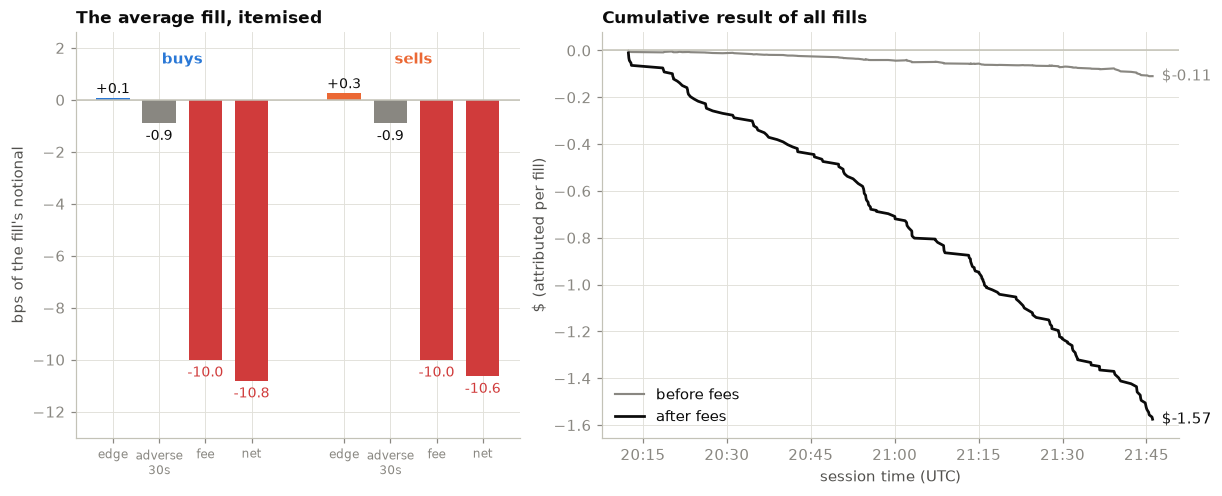

turnover $1,465 across 173 fills
attributed net -1.57 vs booked (cash + inventory at last mid - fees) -1.64 USDT
fees paid 1.47 USDT = 10.0 bps of turnover


In [10]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True, width_ratios=[1, 1.3])

labels = ["edge", "adverse\n30s", "fee", "net"]
for base_x, side, color in [(0, "buy", BUY), (5, "sell", SELL)]:
    sub = pf.filter(pl.col("side") == side)
    edge, adverse, fee = sub["edge_bps"].mean(), sub["mo_30s"].mean(), -sub["fee_bps"].mean()
    net = edge + adverse + fee
    values = [edge, adverse, fee, net]
    colors = [color, MUTED, RED, RED]
    ax.bar([base_x + i for i in range(4)], values, color=colors, width=0.72)
    for i, v in enumerate(values):
        ax.annotate(f"{v:+.1f}", (base_x + i, v), xytext=(0, -11 if v < 0 else 3),
                    textcoords="offset points", ha="center", fontsize=9,
                    color=INK if abs(v) < 5 else RED)
    ax.annotate(f"{side}s", (base_x + 1.5, 1.4), ha="center", color=color, fontweight="bold")
ax.axhline(0, color=BASE, lw=1)
ax.set_ylim(-13, 2.6)
ax.set_xticks([i for i in range(4)] + [5 + i for i in range(4)], labels + labels, fontsize=8)
ax.set_title("The average fill, itemised")
ax.set_ylabel("bps of the fill's notional")

pf = pf.with_columns(
    ((pl.col("edge_bps") + pl.col("mo_30s").fill_null(0.0)) / 1e4 * pl.col("notional")).alias("pnl_gross"),
    ((pl.col("edge_bps") + pl.col("mo_30s").fill_null(0.0) - pl.col("fee_bps")) / 1e4 * pl.col("notional")).alias("pnl_net"),
)
t = ts_col(pf, "received_ts_us")
ax2.plot(t, pf["pnl_gross"].cum_sum(), color=MUTED, lw=1.4, label="before fees")
ax2.plot(t, pf["pnl_net"].cum_sum(), color=INK, lw=1.8, label="after fees")
ax2.axhline(0, color=BASE, lw=1)
for series, color in [(pf["pnl_gross"].cum_sum(), MUTED), (pf["pnl_net"].cum_sum(), INK)]:
    ax2.annotate(f"${series[-1]:+,.2f}", (t[-1], series[-1]), xytext=(6, 0),
                 textcoords="offset points", color=color, va="center", fontsize=9.5)
ax2.set_title("Cumulative result of all fills")
ax2.set_ylabel("$ (attributed per fill)")
ax2.legend(loc="lower left")
ax2.xaxis.set_major_formatter(HHMM)
ax2.set_xlabel("session time (UTC)")
plt.show()

# Trust check: the per-fill attribution should land near the booked result.
bought = pf.filter(pl.col("side") == "buy")
sold = pf.filter(pl.col("side") == "sell")
net_base = bought["booked_qty"].sum() - sold["booked_qty"].sum()
cash = sold["booked_quote"].sum() - bought["booked_quote"].sum()
last_mid = mid["m"][-1]
fees_usdt = (pf["fee_bps"] / 1e4 * pf["notional"]).sum()
booked = cash + net_base * last_mid - fees_usdt
print(f"turnover ${pf['notional'].sum():,.0f} across {pf.height} fills")
print(f"attributed net {pf['pnl_net'].sum():+.2f} vs booked (cash + inventory at last mid - fees) {booked:+.2f} USDT")
print(f"fees paid {fees_usdt:.2f} USDT = {fees_usdt / pf['notional'].sum() * 1e4:.1f} bps of turnover")

## The verdict, in plain English

**Every fill this strategy takes loses money, and the pricing is at fault in three compounding
ways.** The numbers below are from this session's data; re-running the notebook on a new
capture re-derives all of them.

**What we measured.** When our orders traded, the price moved against us straight afterwards —
about half to one basis point within seconds, on *both* sides, and it never bounced back. 92%
of buys and 98% of sells were underwater five seconds after filling. A second, independent
measurement (public trades reaching our quoted prices, no simulator involved) shows the same
thing. Slicing the fills by speed, momentum, book tilt and volatility finds no innocent subset:
the losses are uniform. This is the signature of quotes that are *systematically too close to
the price*, not of one bad episode or one sharp counterparty.

### The three problems, largest first

**1. The fee is not in the price.** The quote calculator solves for the spread that best trades
off fill frequency against risk — but nothing tells it that the exchange takes **10 bps of
every fill** (measured from the recorded commissions; both sides pay it). It quoted 0.1–0.4 bps
of half-spread against an all-in cost of ~10.9 bps (fee + the ~0.9 bps the price takes back).
The quotes were roughly **50× too tight**. No tuning of the model's other inputs can fix a cost
it has never heard of. And the deeper implication is honest but harsh: to break even at this
fee you would have to quote ~$70 away from the price, where a resting order only ever trades in
a violent move — **at a 10 bps maker fee, this market cannot be made profitably at all.** The
fee has to come down (fee tier, BNB discount, zero-fee pair) or the venue has to change (a
market whose natural spread is wider than its fee — the Polymarket engine is exactly that bet)
before any parameter tuning is worth doing.

**2. Even before fees, the quotes don't cover the toxicity.** The grey line in the last figure
shows the fills losing money with the fee set to zero: captured edge ~0.1–0.3 bps per fill vs
~0.9 bps given back to the market afterwards. The model's volatility input is a *per-second*
number, but the damage accrues over 5–30 seconds — it prices risk on a faster clock than the
one the losses run on, so it undercharges even on its own terms.

**3. The inventory nudge parks quotes ON the mid.** When the strategy is short it shades its
buy quote toward the price to attract a fill — sensible in moderation. Here the shading term
routinely exceeded the entire half-spread: the buy quote sat **within one tick of the mid on
69% of all spins** (see the inventory panel). A quote on the mid has zero cushion — every fill
it attracts is pure toxicity plus a fee. Unwinding a $10 lot this way costs more than just
holding it.

### Recommendations

1. **Put the fee in the price.** Floor the half-spread at *fee + measured toxicity* (~11 bps
   here). The engine already computes live markout averages — that floor can be driven by them.
   If the floor is wider than where fills realistically happen, don't quote; flat is a position.
2. **Fix the fee before tuning the model.** Nothing else matters at 10 bps. Get a realistic
   maker tier, or spend the effort on venues where the natural spread exceeds the fee.
3. **Cap the inventory shading** so the unwinding quote always keeps a cushion of at least the
   cost floor. Never quote on the mid.
4. **Price risk on the horizon a fill is actually exposed for** — scale the volatility input to
   the 5–30 s over which the markout losses accrue, not per-second.
5. **Don't quote off a starved fit.** For the first minute of the session the ask-side arrival
   estimate was pinned at its ceiling (e⁵ — a boundary value, not information) because the fit
   had barely seen any events, and the strategy quoted off it anyway: the session's first six
   fills, all sells into a rally, were its worst cohort (−1.16 bps at 30 s vs −0.89 after).
   A railed or data-starved fit should pull that side, not price it.
6. **Re-run this notebook after every change.** The markout curve is the scoreboard: the goal
   is a curve whose 30-second value plus the fee is smaller than the spread being captured.

### Caveats

One 94-minute session and 173 simulated fills: the directions are robust (bootstrap intervals
clear zero almost everywhere), the exact magnitudes are approximate. The simulator's fill model
is optimistic — it assumes queue cancellations happen behind us and cannot see hidden liquidity
— so live markouts would likely be somewhat worse than these.